 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL:** 

**Proyecto Final.**
===
EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 27/05/2025. </p>


---

>**NOTA:** Se asume que el notebook se ejecuta en la carpeta raíz del reporsitorio https://github.com/miccunifi/ISSUES, que las bases de datos *HMC* y *HarMeme* ya se encuentran en *resources*, que todo el código fue modificado para ejecutarse en CPU en lugar de GPU y se añadió el método
>```python
>def predict_step(self, batch):
>        if self.fast_process:
>            image_features = batch['images']
>            text_features = batch['texts']
>        else:
>            image_features, text_features = self.compute_CLIP_features_without_proj(self.clip_model,
>                                                                                    batch['pixel_values'],
>                                                                                    batch['texts'])
>        if self.enh_text:
>            prompt = batch['enhanced_texts']
>        else:
>            prompt = batch['simple_prompt']
>    
>        if self.name in ['hate-clipper', 'adaptation']:
>            image_features = self.image_map(image_features)
>            text_features = self.text_map(text_features)
>            features = torch.mul(image_features, text_features) if self.fusion == 'align' else torch.cat([image_features, text_features], dim=1)
>        elif self.name == 'text-only':
>            features = self.text_map(text_features) if self.proj_map else text_features
>        elif self.name == 'image-only':
>            features = self.image_map(image_features) if self.proj_map else image_features
>        elif self.name == 'sum':
>            features = self.image_map(image_features) + self.text_map(text_features)
>        elif self.name == 'combiner':
>            features = self.comb(self.image_map(image_features), self.text_map(text_features))
>        elif self.name in ['text-inv', 'text-inv-fusion', 'text-inv-comb']:
>            txt_features = self.text_inv(prompt, image_features)
>            img_projection = self.image_map(image_features)
>            if self.name == 'text-inv-fusion':
>                features = torch.cat([txt_features, img_projection], dim=1) if self.fusion == 'concat' else torch.mul(txt_features, img_projection)
>            elif self.name == 'text-inv-comb':
>                features = self.comb(img_projection, txt_features)
>            else:
>                features = txt_features
>        else:
>            raise ValueError()
>    
>        features_pre_output = self.pre_output(features)
>        logits = self.output(features_pre_output).squeeze(dim=1)  # [batch_size]
>        prob = torch.sigmoid(logits)
>        pred_class = (prob >= 0.5).long()
>    
>        return prob, pred_class
>```
> A la clase *HateClassifier* de engine.py.

In [1]:
# Necessary libraries.
import sys                                       # for system-specific parameters and functions.
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'
import warnings
warnings.filterwarnings('ignore', category = UserWarning, module = 'tqdm')
sys.path.append('./src')                         # add the src directory to the system path.
from engine import HateClassifier, create_model  # import the HateClassifier and create_model functions.
from datasets import MemesDataset                # import the MemesDataset class.
import clip                                      # import the CLIP model for image and text processing.
import torch                                     # import PyTorch for tensor operations.
from pytorch_lightning import Trainer            # import the Trainer class from PyTorch Lightning.
from pytorch_lightning.loggers import CSVLogger  # import the CSVLogger for logging training metrics.
from datasets import load_dataset, MemesCollator # import the load_dataset function and MemesCollator class.
from engine import HateClassifier                # import the HateClassifier class.
import pandas as pd                              # import pandas for data manipulation.
import matplotlib.pyplot as plt                  # import matplotlib for plotting.
from torch.utils.data import DataLoader          # import DataLoader for batching data.
from PIL import Image                            # import PIL for image processing.

# **1.- Load the trained models**

>Se cargan los argumentos para instanciar los modelos entrenados:

In [2]:
class HarArgs:
    dataset = 'harmeme'
    image_size = 224
    num_mapping_layers = 1
    map_dim = 768
    fusion = 'align'
    num_pre_output_layers = 3
    drop_probs = [0.2, 0.4, 0.1]
    gpus = '-1'
    batch_size = 64
    lr = 0.000013
    weight_decay = 1e-4
    max_epochs = 60
    max_steps = -1
    name = 'text-inv-comb'
    pretrained_proj_weights = True
    freeze_proj_layers = True
    comb_proj = True
    comb_fusion = 'align'
    convex_tensor = False
    phi_inv_proj = True
    text_inv_proj = True
    post_inv_proj = True
    enh_text = True
    phi_freeze = True
    fast_process = True
    proj_map = True

class HmcArgs:
    dataset = 'hmc'
    image_size = 224
    num_mapping_layers = 1
    map_dim = 1024
    fusion = 'align'
    num_pre_output_layers = 1
    drop_probs = [0.2, 0.4, 0.1]
    gpus = '0'
    batch_size = 64
    lr = 0.0001
    weight_decay = 1e-4
    max_epochs = 60
    max_steps = -1
    name = 'text-inv-comb'
    pretrained_model = 'hmc_text-inv-comb_best.ckpt'
    reproduce = True
    pretrained_proj_weights = True
    freeze_proj_layers = True
    comb_proj = True
    comb_fusion = 'align'
    convex_tensor = False
    phi_inv_proj = True
    text_inv_proj = True
    post_inv_proj = True
    enh_text = True
    phi_freeze = True
    fast_process = True
    proj_map = True

args_har = HarArgs()
args_hmc = HmcArgs()

- **Se cargan los modelos preentrenados:**
Se usa HateClassifier.load_from_checkpoint para cargar los checkpoints guardados, pasándole los argumentos (args) y especificando que se cargue en CPU.

- **Se preparan los datasets de validación y testeo para cada caso:**
Se construyen los DataLoader para los splits 'val' (validación) y 'test', usando el collator MemesCollator que organiza cómo se forman los batches. Se asigna un número de num_workers=0 por compatibilidad sencilla en notebook.

- **Se configura el Trainer de PyTorch Lightning:**
Se inicializa el Trainer para correr sobre CPU y usando un logger local tipo CSV (guardar logs en carpetas logs/test_run).

In [ ]:
# Load the Harmeme model from a checkpoint.
model_har = HateClassifier.load_from_checkpoint(
    'resources/pretrained_models/harmeme_text-inv-comb_best.ckpt',
    args = args_har, map_location = torch.device('cpu')
)
# Load the Facebook/HMC model from a checkpoint.
model_hmc = HateClassifier.load_from_checkpoint(
    'resources/pretrained_models/hmc_text-inv-comb_best.ckpt',
    args = args_hmc, map_location = torch.device('cpu')
)

# Set the models to evaluation mode.
model_har.eval()
model_hmc.eval()

# Load the dataset and create a collator_har for batching.
collator_har = MemesCollator(args_har)
collator_hmc = MemesCollator(args_hmc)
dataset_val_har = load_dataset(args = args_har, split = 'val')
dataset_test_har = load_dataset(args = args_har, split = 'test')
dataset_val_hmc = load_dataset(args = args_hmc, split = 'dev_seen')
dataset_test_hmc = load_dataset(args = args_hmc, split = 'test_seen')

# Create DataLoaders for validation and test datasets.
dataloader_val_har = DataLoader(
    dataset_val_har, batch_size = args_har.batch_size, collate_fn = collator_har, num_workers = 0)
dataloader_test_har = DataLoader(
    dataset_test_har, batch_size = args_har.batch_size, collate_fn = collator_har, num_workers = 0)
dataloader_val_hmc = DataLoader(
    dataset_val_hmc, batch_size = args_hmc.batch_size, collate_fn = collator_hmc, num_workers = 0)
dataloader_test_hmc = DataLoader(
    dataset_test_hmc, batch_size = args_hmc.batch_size, collate_fn = collator_hmc, num_workers = 0)

# Configure the trainers with a CSV logger.
logger_har = CSVLogger('logs', name = 'test_run')
trainer_har = Trainer(accelerator = 'cpu', devices = 1, logger = logger_har)
logger_hmc = CSVLogger('logs', name = 'facebook_test_run')
trainer_hmc = Trainer(accelerator = 'cpu', devices = 1, logger = logger_hmc)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


- **Se ejecuta el testeo (validation + test set):**
Se llama trainer.test() pasando tanto el dataloader de validación como el de testeo, y al final se imprimen los resultados obtenidos.

In [4]:
# Evaluate the models on the validation and test datasets.
print("Evaluating Harmeme model on val + test...")
test_results_har = trainer_har.test(model_har, dataloaders = [dataloader_val_har, dataloader_test_har])
print("Test results:")
print(test_results_har)

print('')
print("Evaluating Facebook/HMC model on dev_seen (val) + test_seen...")
test_results_hmc = trainer_hmc.test(model_hmc, dataloaders = [dataloader_val_hmc, dataloader_test_hmc])
print("Facebook/HMC test results:")
print(test_results_hmc)

Evaluating Harmeme model on val + test...
Testing DataLoader 1: 100%|██████████| 6/6 [00:08<00:00,  1.41s/it]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0             DataLoader 1
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test/accuracy                                  0.8163841962814331
       test/auroc                                    0.9282916188240051
      val/accuracy           0.700564980506897
        val/auroc           0.8901458382606506
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results:
[{'val/accuracy/dataloader_idx_0': 0.700564980506897, 'val/auroc/dataloader_idx_0': 0.8901458382606506}, {'test/accuracy/dataloader_idx_1': 0.8163841962814331, 'test/auroc/dataloader_idx_1': 0.9282916188240

# **2.- Inference**

In [5]:
def predict_external_image(image_path: str, prompt_text: str, model: HateClassifier,
                           model_type: str = 'har', device: str = 'cpu', show: bool = True):
    
    if model_type == 'har':
        clip_model, preprocess = clip.load("ViT-L/14", device=device, jit=False)
        adapter = torch.nn.Linear(768, 1024)
    elif model_type == 'hmc':
        clip_model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
        adapter = torch.nn.Linear(512, 1024)
    else:
        raise ValueError("model_type must be 'har' or 'hmc'.")

    # Preprocess the image and tokenize the text prompt
    image_input = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    prompt_for_model = prompt_text if prompt_text.strip().endswith('$') else prompt_text + ' $'
    text_token = clip.tokenize([prompt_for_model]).to(device)

    # Get image features using CLIP model.
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input).float()

    # If the image features do not match the model's expected input size, adapt them.
    if image_features.shape[1] != model.image_map.proj[0].in_features:
        image_features = adapter(image_features)

    # Load the model to the specified device.
    batch = {
        'images': image_features,     # Image features from CLIP.
        'texts': text_token,          # Tokenized text prompt.
        'enhanced_texts': text_token, # Enhanced text features (if applicable).
        'simple_prompt': text_token,  # Simple prompt for the model.   
        'labels': torch.tensor([0])   # Dummy label for inference, not used in evaluation.
    }

    # Run the model's predict step
    with torch.no_grad():
        prob_tensor, pred_class_tensor = model.predict_step(batch)
    
    prob = prob_tensor.item()
    pred_class = pred_class_tensor.item()

    # Display the image with the prediction
    if show:
        img_show = Image.open(image_path)
        plt.imshow(img_show)
        plt.axis('off')
        plt.title(f'Prompt: {prompt_text}, Prediction: {pred_class}, Probability: {prob:.4f}')
        plt.show()
    
    return prob, pred_class

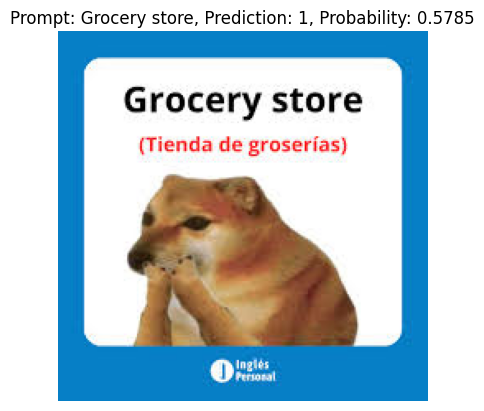

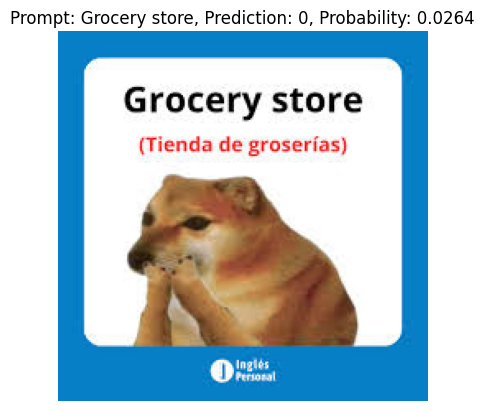

(0.026432806625962257, 0)

In [7]:
image_path = './pruebas/grosery_store.jpg'
prompt_text = "Grocery store"

predict_external_image(image_path, prompt_text, model_har, model_type = 'har', device = 'cpu')
predict_external_image(image_path, prompt_text, model_hmc, model_type = 'hmc', device = 'cpu')

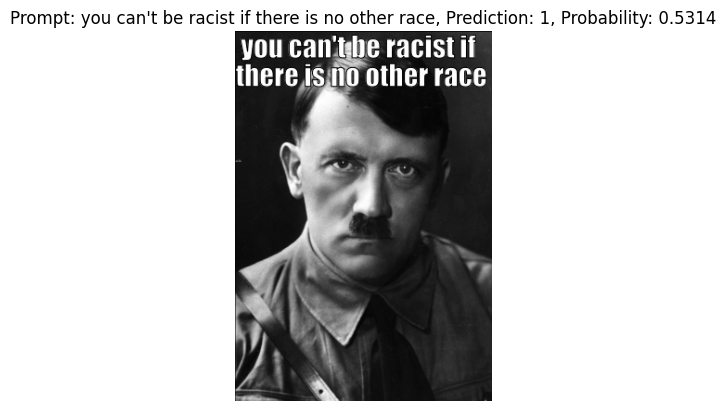

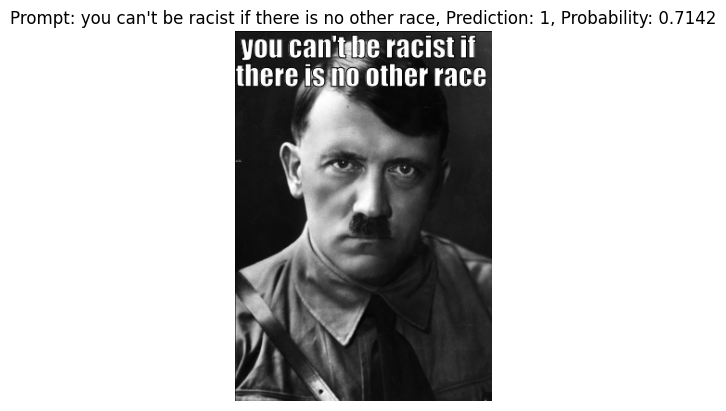

(0.7142325043678284, 1)

In [7]:
image_path = './pruebas/01247.png'
prompt_text = "you can't be racist if there is no other race"

predict_external_image(image_path, prompt_text, model_har, model_type = 'har', device = 'cpu')
predict_external_image(image_path, prompt_text, model_hmc, model_type = 'hmc', device = 'cpu')

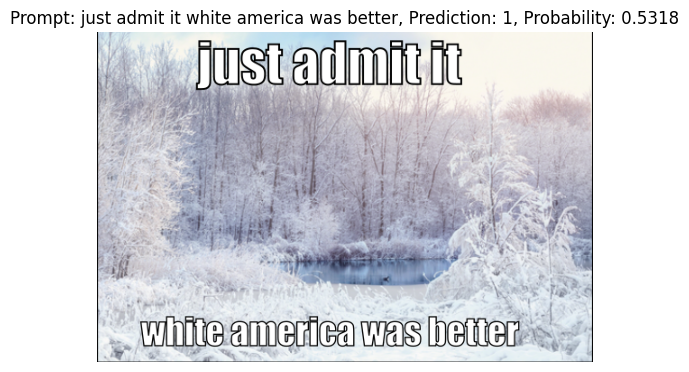

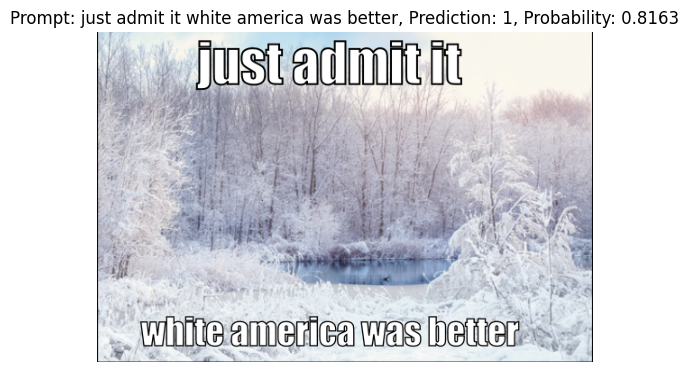

(0.8163085579872131, 1)

In [8]:
image_path = './pruebas/02751.png'
prompt_text = "just admit it white america was better"

predict_external_image(image_path, prompt_text, model_har, model_type = 'har', device = 'cpu')
predict_external_image(image_path, prompt_text, model_hmc, model_type = 'hmc', device = 'cpu')

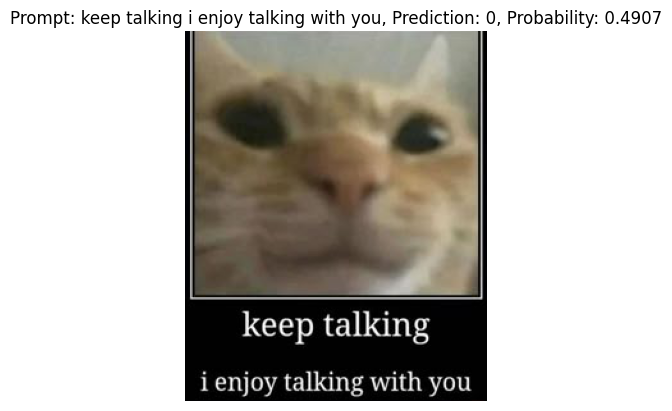

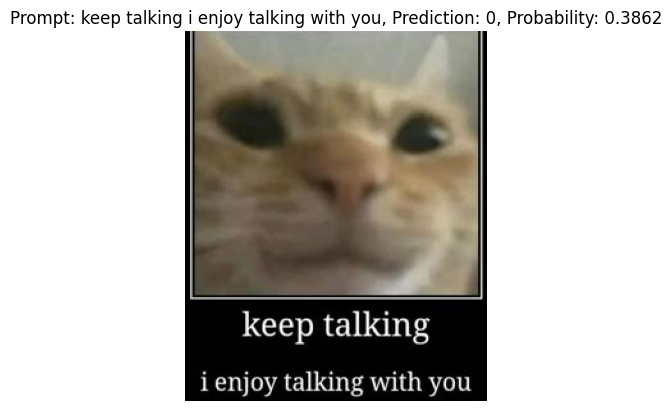

(0.3861895799636841, 0)

In [14]:
image_path = './pruebas/cat.jpg'
prompt_text = "keep talking i enjoy talking with you"

predict_external_image(image_path, prompt_text, model_har, model_type = 'har', device = 'cpu')
predict_external_image(image_path, prompt_text, model_hmc, model_type = 'hmc', device = 'cpu')

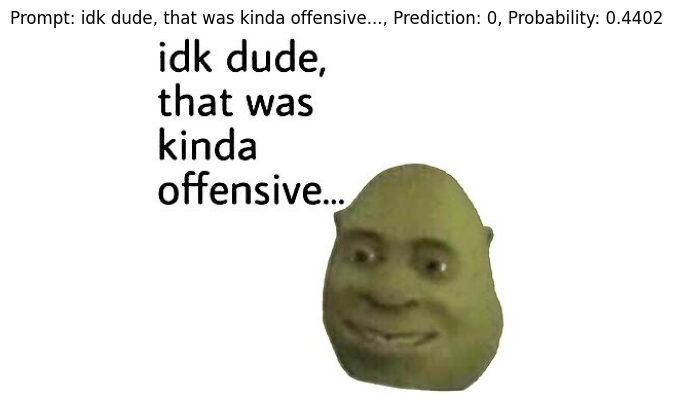

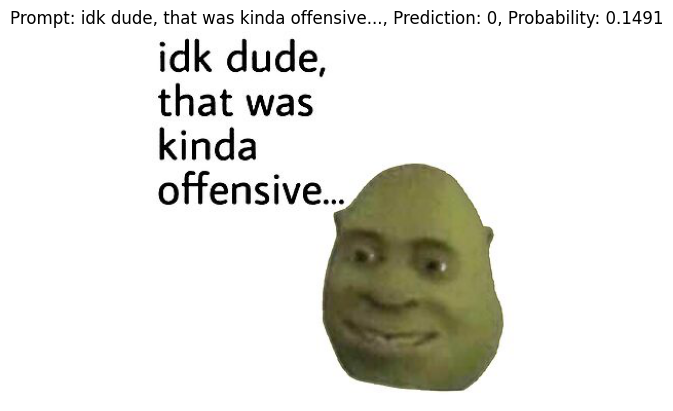

(0.14909474551677704, 0)

In [16]:
image_path = './pruebas/shrek.jpg'
prompt_text = "idk dude, that was kinda offensive..."

predict_external_image(image_path, prompt_text, model_har, model_type = 'har', device = 'cpu')
predict_external_image(image_path, prompt_text, model_hmc, model_type = 'hmc', device = 'cpu')

# **3.- Comparación**

In [8]:
def get_random_examples(csv_path: str, img_folder: str, num_samples: int = 4, img_column:str = 'img'):
    df = pd.read_csv(csv_path)
    selected = df.sample(n = num_samples)
    image_paths = []
    prompts = []
    for _, row in selected.iterrows():
        img_name = os.path.basename(row[img_column])
        full_path = os.path.join(img_folder, img_name)
        if os.path.exists(full_path):
            image_paths.append(full_path)
            prompts.append(row['text'])
        else:
            print(f"File not found: {full_path}")
    return image_paths, prompts

def plot_side_by_side_dual_models(image_paths: str, prompts: str, model_har: str, model_hmc: str, device: str = 'cpu'):
    for img_path, prompt in zip(image_paths, prompts):
        prob_har, pred_har = predict_external_image(img_path, prompt, model_har, model_type = 'har', device = device, show = False)
        prob_hmc, pred_hmc = predict_external_image(img_path, prompt, model_hmc, model_type = 'hmc', device = device, show = False)

        img = plt.imread(img_path)
        fig, axes = plt.subplots(1, 2, figsize = (10,5))
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title(f'HAR -> Pred: {pred_har}, p = {prob_har:.2f}')

        axes[1].imshow(img)
        axes[1].axis('off')
        axes[1].set_title(f'HMC -> Pred: {pred_hmc}, p = {prob_hmc:.2f}')

        plt.suptitle(f'Prompt: {prompt}', fontsize = 10)
        plt.show()

Plotting HAR images with HAR vs HMC predictions


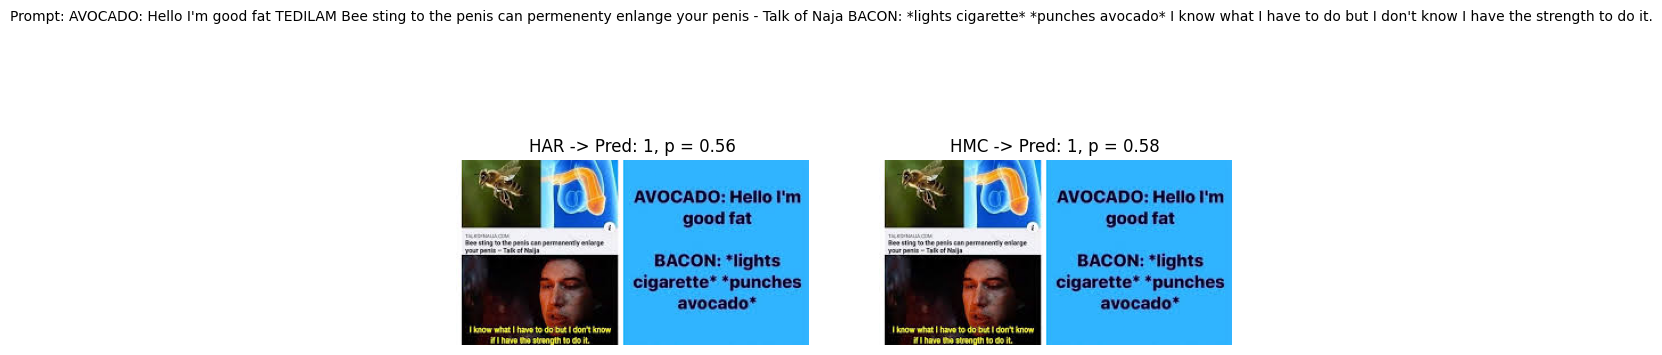

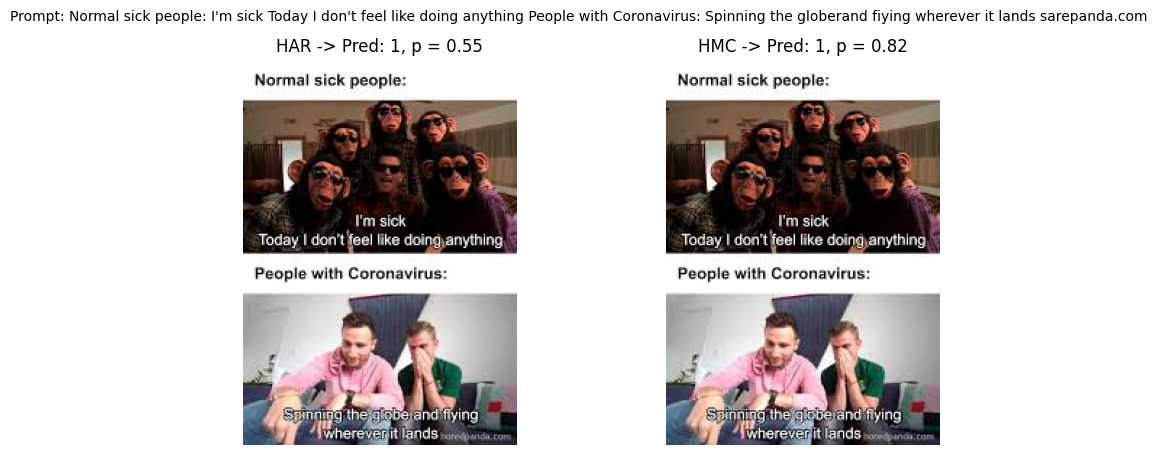

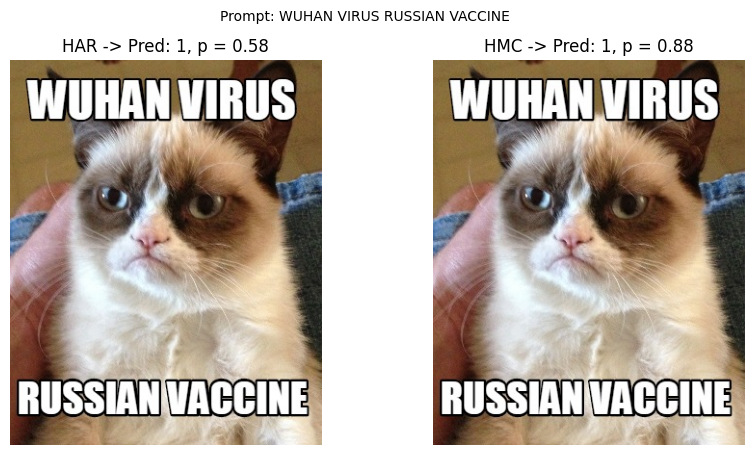

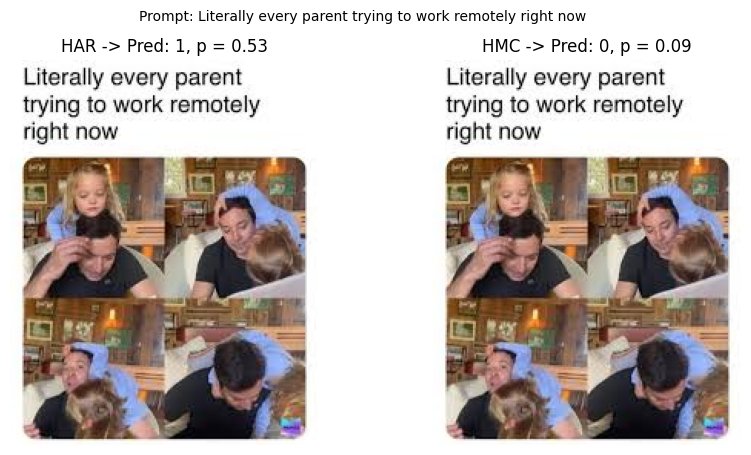

In [10]:
# === HAR ===
har_csv = './resources/datasets/harmeme/labels/harmeme_info.csv'
har_img_folder = './resources/datasets/harmeme/img'
har_image_paths, har_prompts = get_random_examples(har_csv, har_img_folder, img_column = 'image')

print("Plotting HAR images with HAR vs HMC predictions")
plot_side_by_side_dual_models(har_image_paths, har_prompts, model_har, model_hmc, device = 'cpu')


Plotting HMC images with HAR vs HMC predictions


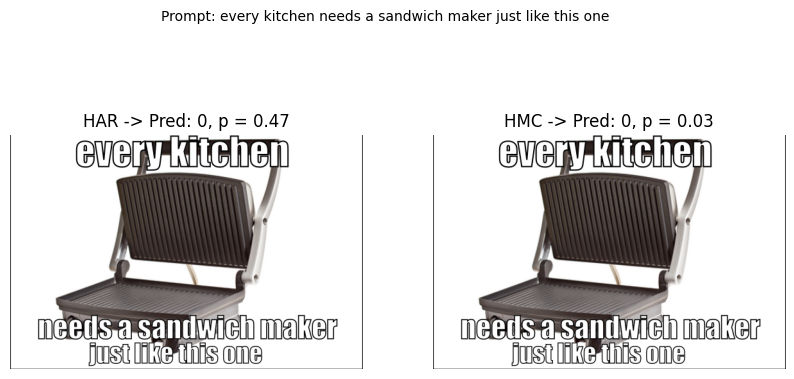

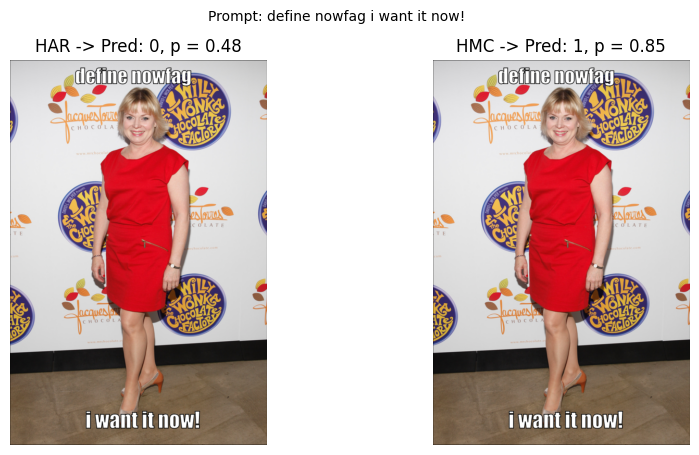

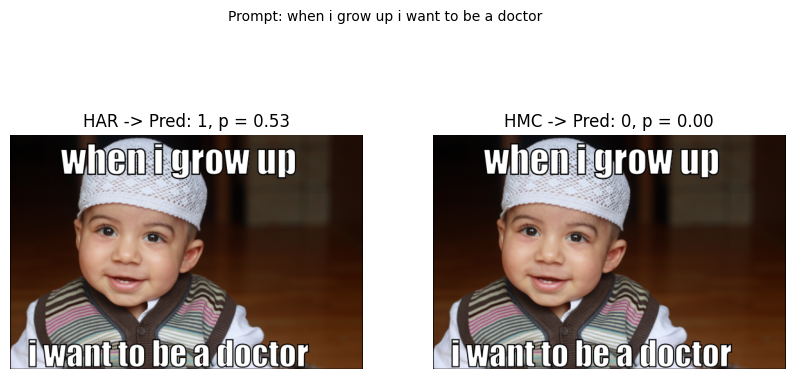

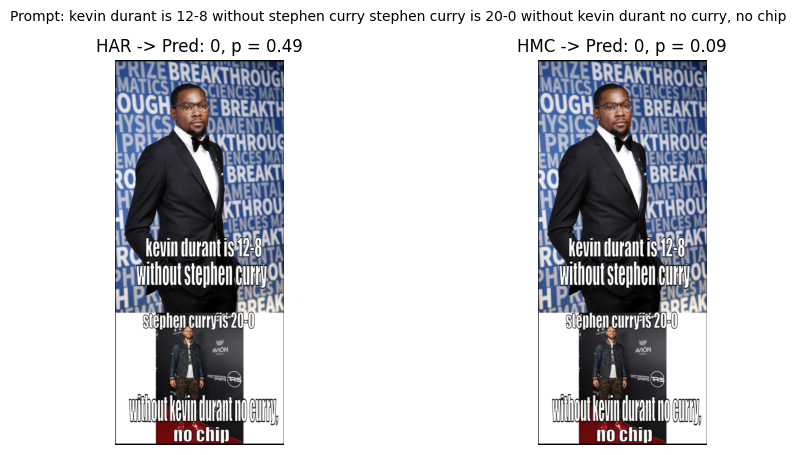

In [42]:
hmc_csv = './resources/datasets/hmc/labels/hmc_info.csv'
hmc_img_folder = './resources/datasets/hmc/img'
hmc_image_paths, hmc_prompts = get_random_examples(hmc_csv, hmc_img_folder, img_column = 'img')

print("Plotting HMC images with HAR vs HMC predictions")
plot_side_by_side_dual_models(hmc_image_paths, hmc_prompts, model_har, model_hmc, device = 'cpu')